In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np


In [2]:
(Xtr,ytr),(Xts,yts)=mnist.load_data()
Xtr=Xtr/255
Xts=Xts/255

In [3]:
print(Xtr.shape)


(60000, 28, 28)


In [4]:
#reshape to 4D
Xtr=Xtr.reshape(Xtr.shape[0],28,28,1)
print(Xtr.shape)
Xts=Xts.reshape(Xts.shape[0],28,28,1)

(60000, 28, 28, 1)


In [5]:
idg=ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

idg.fit(Xtr)


In [6]:


initial_learning_rate=0.01
batch_size=64
epochs=20
def lr_schedule(epoch,lr):
    if epoch>0 and epoch%3==0:
        return lr/2
    return lr



In [7]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dropout(0.2),
    Dense(64,activation="relu"),
    Dropout(0.2),
    Dense(10,activation="softmax")
]
)


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
ytr=to_categorical(ytr,10)
yts=to_categorical(yts,10)

optimizer=SGD(learning_rate=initial_learning_rate)
model.compile(optimizer=optimizer,loss="categorical_crossentropy",metrics=["accuracy"])

In [9]:
#Early stopping
er=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True

)

In [10]:
lr_scheduler=LearningRateScheduler(lr_schedule)
history=model.fit(Xtr,ytr,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(Xts,yts),
          callbacks=[lr_scheduler,er])


Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6593 - loss: 1.1261 - val_accuracy: 0.8814 - val_loss: 0.4575 - learning_rate: 0.0100
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8406 - loss: 0.5366 - val_accuracy: 0.9075 - val_loss: 0.3347 - learning_rate: 0.0100
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8734 - loss: 0.4308 - val_accuracy: 0.9185 - val_loss: 0.2882 - learning_rate: 0.0100
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8864 - loss: 0.3847 - val_accuracy: 0.9236 - val_loss: 0.2686 - learning_rate: 0.0050
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8936 - loss: 0.3650 - val_accuracy: 0.9263 - val_loss: 0.2560 - learning_rate: 0.0050
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8990 - loss: 0.3470 - val_accuracy: 0.9292 - val_loss: 0.2443 - learning_rate: 0.0050
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9020 - loss: 0.3351 - 

In [11]:
test_loss,test_accuracy=model.evaluate(Xts,yts)
print(test_loss,test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9369 - loss: 0.2157
0.21567831933498383 0.9369000196456909


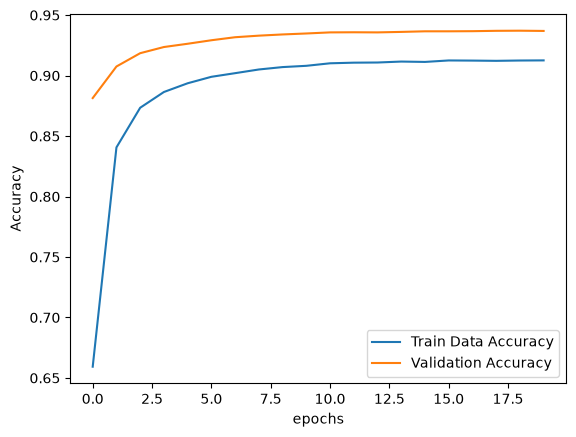

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="Train Data Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.show()

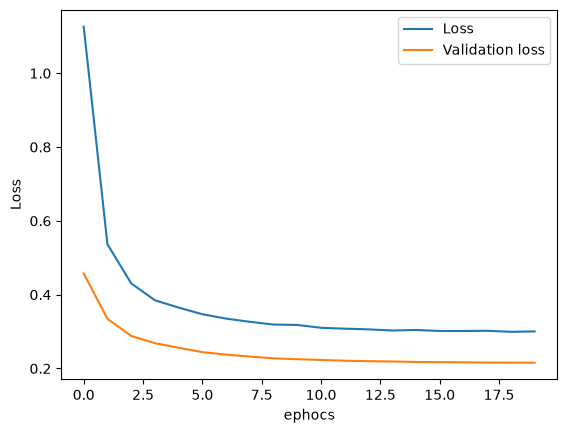

In [13]:
plt.plot(history.history["loss"],label="Loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.legend()
plt.xlabel("ephocs")
plt.ylabel("Loss")
plt.show()